# Download the prerequisites
1. Tensorflow
2. Numpy
3. Matplotlib
4. Gradio
5. Sklearn
6. Seaborn

In [37]:
%pip install tensorflow
%pip install numpy
%pip install matplotlib
%pip install Gradio
%pip install scikit-learn
%pip install seaborn

13777.28s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


13783.11s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


13788.92s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


...


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


13800.69s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 3.5 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 1.9 MB/s  0:00:18m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


13837.83s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# DATA ACQUISITION
## Step 1: Load the Datasets

### legend:
#### data_dir = directory of the data / data path
#### train_ds = means train Data set
#### validation_ds = means Validation Dataset

In [11]:
import tensorflow as tf

data_dir = "cat_breeds"
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset="training",
    seed=123,
    image_size=(180, 180),
    batch_size=32
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(180, 180),
    batch_size=32
)

Found 1349 files belonging to 10 classes.
Using 1080 files for training.
Found 1349 files belonging to 10 classes.
Using 269 files for validation.


E0000 00:00:1788531114.326055   43389 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Data Exploration

In [18]:
#print the shape of the loaded data
# Grab one batch from the training set
for images, labels in train_ds.take(1):
    print("Train batch X shape (images):", images.shape)
    print("Train batch y shape (labels):", labels.shape)

# Grab one batch from the validation set
for images, labels in validation_ds.take(1):
    print("Validation batch X shape (images):", images.shape)
    print("Validation batch y shape (labels):", labels.shape)

Train batch X shape (images): (32, 180, 180, 3)
Train batch y shape (labels): (32,)
Validation batch X shape (images): (32, 180, 180, 3)
Validation batch y shape (labels): (32,)


In [13]:
#Print the class names
print("Cat breeds:", train_ds.class_names)
#Print the number of classes
print("Number of cat breeds:", len(train_ds.class_names))

Cat breeds: ['abyssinian', 'bengal', 'birman', 'british_shorthair', 'maine_coon', 'oriental_shorthair', 'persian', 'siamese', 'sphynx', 'turkish_van']
Number of cat breeds: 10


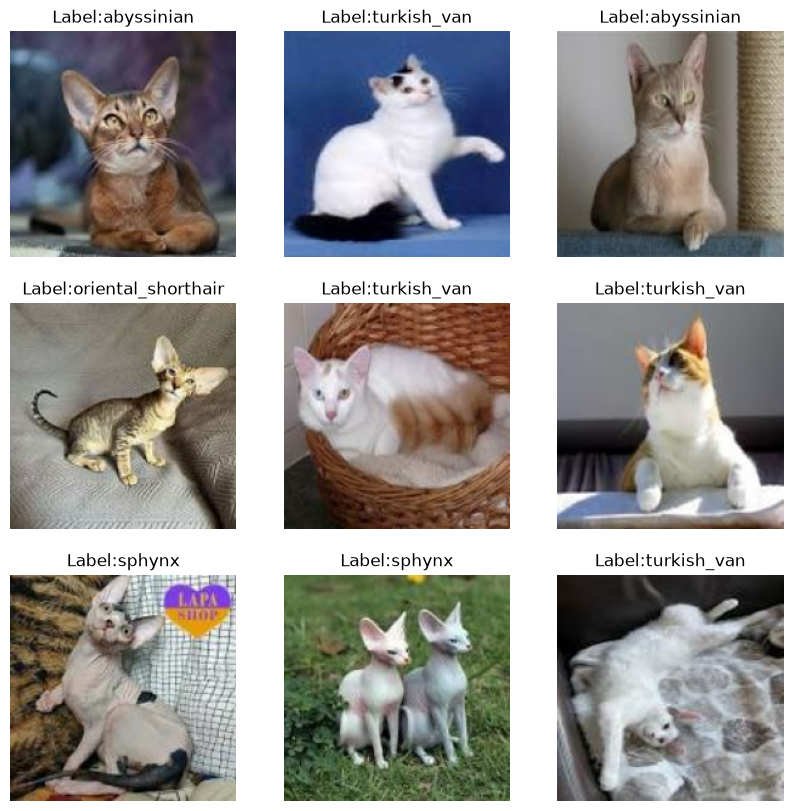

In [23]:
import matplotlib.pyplot as plt
import numpy as np

#display the first 9 images
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(
            f"Label:{train_ds.class_names[labels[i]]}"
        )
        plt.axis('off')
plt.show()


# Step 2: Data Reprocessing

In [26]:
#function to rescale images
def rescale(images, labels):
    return tf.cast(images, tf.float32) / 255.0 , labels

train_ds  = train_ds.map(rescale)
validation_ds = validation_ds.map(rescale)

print(f"train_ds after scaling: {train_ds}")
print(f"validation_ds after scaling: {validation_ds}")


train_ds after scaling: <_MapDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
validation_ds after scaling: <_MapDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


# Model Creation

In [57]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Input shape: height, width, color channels
    layers.Input(shape=(180, 180, 3)),
    
    #randomly flip the images
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    
    # Feature extraction (Convolutions + Pooling)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten features into a 1D vector
    layers.Flatten(),
    
    # Classification head
    layers.Dense(128, activation='relu'),
    layers.Dense(10)
])

#compiling the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics = ['accuracy'])

model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,648,266 (25.36 MB)

 Trainable params: 6,648,266 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

# Training the Model

In [58]:
history = model.fit(train_ds, validation_data= validation_ds, epochs= 10)


Epoch 1/10


/home/laurencejhonadominguez/Documents/IAi/reverse_engineered/.venv/lib64/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


34/34 ━━━━━━━━━━━━━━━━━━━━ 37s 976ms/step - accuracy: 0.1556 - loss: 2.4440 - val_accuracy: 0.1933 - val_loss: 2.2241
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 31s 907ms/step - accuracy: 0.2639 - loss: 2.1015 - val_accuracy: 0.2454 - val_loss: 2.1260
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 31s 921ms/step - accuracy: 0.2833 - loss: 2.0299 - val_accuracy: 0.2528 - val_loss: 2.0148
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 32s 930ms/step - accuracy: 0.3269 - loss: 1.9111 - val_accuracy: 0.2751 - val_loss: 1.9730
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 32s 938ms/step - accuracy: 0.3343 - loss: 1.8722 - val_accuracy: 0.3011 - val_loss: 1.9659
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 32s 951ms/step - accuracy: 0.3389 - loss: 1.8753 - val_accuracy: 0.2974 - val_loss: 1.9749
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 31s 915ms/step - accuracy: 0.3694 - loss: 1.7561 - val_accuracy: 0.2974 - val_loss: 1.9754
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 32s 932ms/step - accuracy: 0.4102 - loss: 1.6723 - val_accuracy: 0.267

# Visualize the Training History

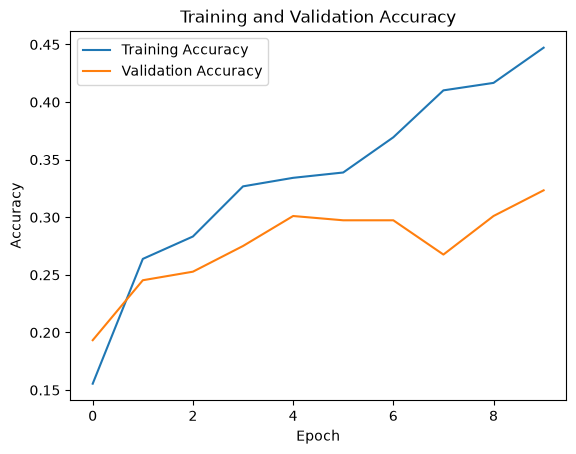

In [59]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

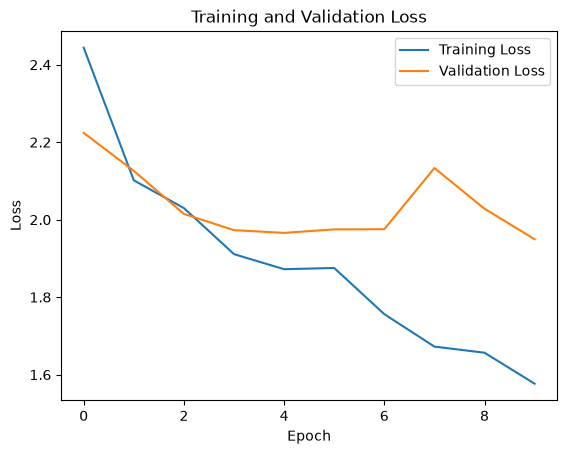

In [60]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Predictions

In [61]:
# Generate predictions
predictions = model.predict(train_ds)
# Print the shape of the predictions
print("Predictions shape:", predictions.shape)

34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 200ms/step
Predictions shape: (1080, 10)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


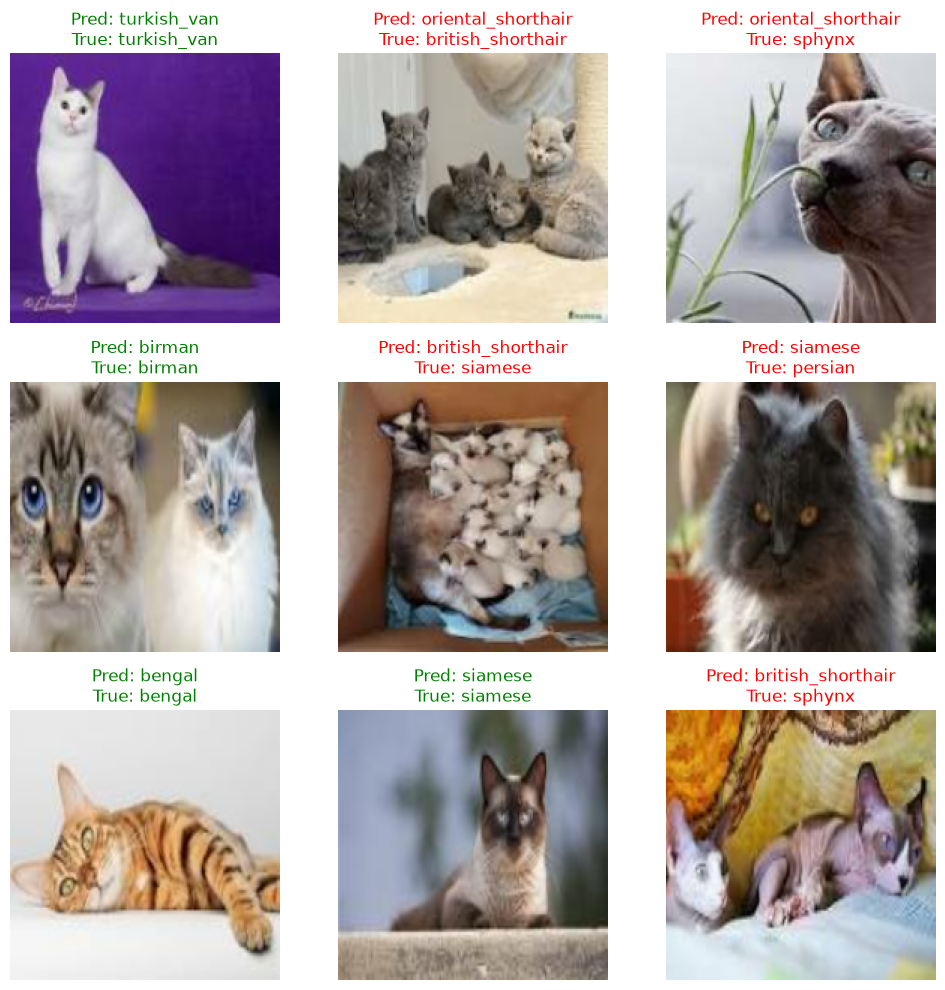

In [62]:
import os
import matplotlib.pyplot as plt
import numpy as np

class_names = sorted(os.listdir("cat_breeds"))
# 1. Grab one batch (32 images and their true labels)
for images, labels in validation_ds.take(1):
    # 2. Predict on this single batch
    batch_predictions = model.predict(images)
    
    # 3. Plot the first 9 images from this batch
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        
        # Display the image
        plt.imshow(images[i].numpy())
        
        # Determine labels
        predicted_label = class_names[np.argmax(batch_predictions[i])]
        actual_label = class_names[labels[i].numpy()]
        
        # Green title if correct, Red if wrong
        color = "green" if predicted_label == actual_label else "red"
        
        plt.title(f"Pred: {predicted_label}\nTrue: {actual_label}", color=color)
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()
    break

# Model evaluation

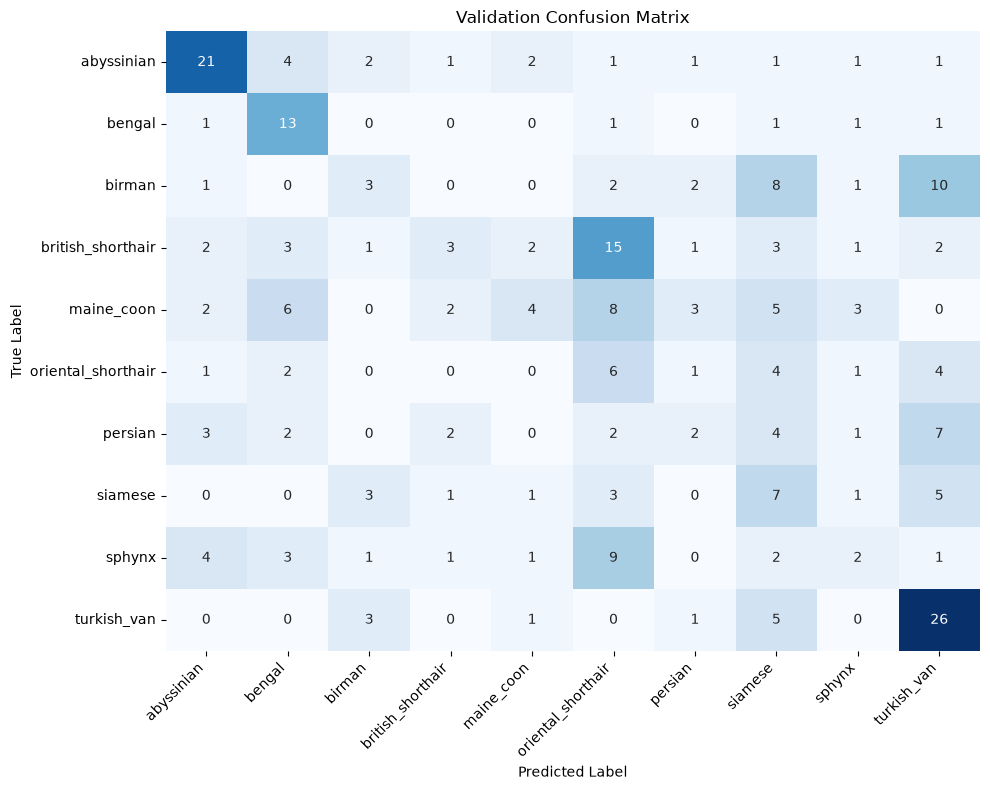

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Extract true labels and predictions from the validation set
true_labels = []
predicted_classes = []

for images, labels in validation_ds:
    preds = model.predict(images, verbose=0)
    predicted_classes.extend(np.argmax(preds, axis=1))
    true_labels.extend(labels.numpy())

# Convert to numpy arrays
true_labels = np.array(true_labels)
predicted_classes = np.array(predicted_classes)

# 2. Compute the confusion matrix
cm = confusion_matrix(true_labels, predicted_classes)

# 3. Plot using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Validation Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [65]:
from sklearn.metrics import classification_report

# Generate the classification report using the arrays from earlier
report = classification_report(
    true_labels, 
    predicted_classes, 
    target_names=class_names
)

# Print the classification report
print(report)

                    precision    recall  f1-score   support

        abyssinian       0.60      0.60      0.60        35
            bengal       0.39      0.72      0.51        18
            birman       0.23      0.11      0.15        27
 british_shorthair       0.30      0.09      0.14        33
        maine_coon       0.36      0.12      0.18        33
oriental_shorthair       0.13      0.32      0.18        19
           persian       0.18      0.09      0.12        23
           siamese       0.17      0.33      0.23        21
            sphynx       0.17      0.08      0.11        24
       turkish_van       0.46      0.72      0.56        36

          accuracy                           0.32       269
         macro avg       0.30      0.32      0.28       269
      weighted avg       0.32      0.32      0.29       269



In [66]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelBinarizer
# 1. Gather all validation probabilities and true labels
val_probs = []
val_labels = []

for images, labels in validation_ds:
    # Get raw logits from the model
    logits = model.predict(images, verbose=0)
    # Convert logits into valid probabilities (0.0 to 1.0)
    probs = tf.nn.softmax(logits).numpy()
    
    val_probs.extend(probs)
    val_labels.extend(labels.numpy())

val_probs = np.array(val_probs)
val_labels = np.array(val_labels)
# Convert true labels to one-hot encoding for ROC AUC calculation
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(val_labels)

# Calculate ROC AUC for each class
roc_auc_scores = roc_auc_score(y_test_bin, val_probs, average=None)

# Print the ROC AUC scores for each class
for i, score in enumerate(roc_auc_scores):
    print(f"ROC AUC for class {i}: {score:.4f}")

# Calculate macro-average ROC AUC
macro_roc_auc = roc_auc_score(y_test_bin, val_probs, average='macro')
print(f"\nMacro-average ROC AUC: {macro_roc_auc:.4f}")

ROC AUC for class 0: 0.8812
ROC AUC for class 1: 0.8951
ROC AUC for class 2: 0.8027
ROC AUC for class 3: 0.7574
ROC AUC for class 4: 0.7463
ROC AUC for class 5: 0.6680
ROC AUC for class 6: 0.6615
ROC AUC for class 7: 0.8130
ROC AUC for class 8: 0.5845
ROC AUC for class 9: 0.8414

Macro-average ROC AUC: 0.7651


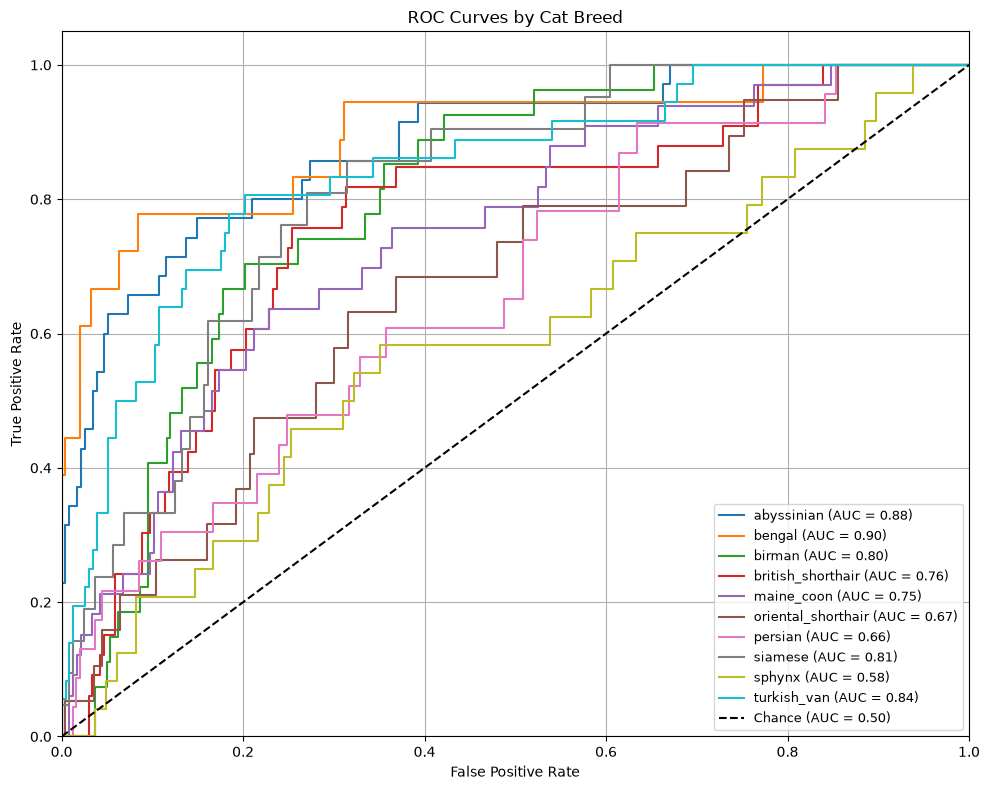

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc, roc_curve
from sklearn.preprocessing import LabelBinarizer

# 1. One-hot encode the validation labels
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(val_labels)

# 2. Plot ROC curves for all 10 cat breeds
plt.figure(figsize=(10, 8))

for i in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], val_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

# 3. Formatting
plt.plot([0, 1], [0, 1], "k--", label="Chance (AUC = 0.50)")
plt.title("ROC Curves by Cat Breed")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()